## The Greg Method

In [15]:
from custom.util.data_manipulation import load_and_process_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loaded variable 'df' from URI: /home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/data/claims_train.csv
df = pd.read_csv(r'data/claims_train.csv')
df.loc[df["Exposure"]>1, "Exposure"] = 1
df = df.loc[df["VehAge"] < 30, :]

df["DrivAgeCat"] = "Normal"
df.loc[df["DrivAge"] < 25, "DrivAgeCat"] = "Young"
df.loc[df["DrivAge"] > 70, "DrivAgeCat"] = "Old"

# Interaction term?
df["VehAge**2"] = df["VehAge"] ** 2
df["BonusMalus**2"] = df["BonusMalus"] ** 2
df["DrivAge**2"] = df["DrivAge"] ** 2
df['BonusMalusBin'] = pd.cut(df['BonusMalus'], bins=[0, 75, 100, 150, 1000], labels=['Low', "Medium", 'Higher', 'High'])
# df["VehPow_x_DrivAge"] = df["VehPower"] * df["DrivAge"]

K = 0.5 # Smoothing constant
Z = df["Exposure"] / (df["Exposure"] + K) # Credibility factor, if Exposure is high, Z -> 1, else Z -> 0
avg_freq = df["ClaimNb"].sum() / df["Exposure"].sum()

df["Risk"] = Z * (df["ClaimNb"] / df["Exposure"]) + (1 - Z) * avg_freq # Bayesian credibility formula, if Z -> 1, use individual frequency, else pull outliers to avg frequency, so
                                                                           # if Exposure is low, use avg frequency because bad luck could have caused high ClaimNb
df["Risk"] = np.log(df["Risk"] + 1)

numeric_columns = ["BonusMalus", "Density", "DrivAge", "VehAge"]
categorical_columns = ["VehBrand", "VehPower", "DrivAgeCat", "BonusMalusBin", "Region", "Area", "VehGas"]

df.reset_index(inplace=True, drop=True)

# df.drop(df[(df["ClaimNb"] == 0) & (df["BonusMalus"] > 100)].index, inplace=True, axis=0)
# df.drop(df[(df["ClaimNb"] == 2) & (df["BonusMalus"] <= 100)].index, inplace=True, axis=0)
# df.drop(df[(df["ClaimNb"] == 1) & (df["BonusMalus"] <= 50) & (df["Exposure"] < 0.5)].index, inplace=True, axis=0)

X = df[numeric_columns + categorical_columns]
X = pd.get_dummies(X, columns=categorical_columns)
y = df['Risk']
df.sort_values("Risk")

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,DrivAgeCat,VehAge**2,BonusMalus**2,DrivAge**2,BonusMalusBin,Risk
127347,3184438.0,0,1.00,A,6,7,36,54,B2,Diesel,27,R24,Normal,49,2916,1296,Low,0.032999
127325,166529.0,0,1.00,D,4,12,42,50,B4,Diesel,1974,R54,Normal,144,2500,1764,Low,0.032999
500769,2082583.0,0,1.00,D,7,8,58,50,B5,Regular,1601,R41,Normal,64,2500,3364,Low,0.032999
500765,50611.0,0,1.00,A,6,1,44,50,B3,Diesel,21,R11,Normal,1,2500,1936,Low,0.032999
322682,1127712.0,0,1.00,E,7,5,67,50,B10,Diesel,2103,R25,Normal,25,2500,4489,Low,0.032999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88204,2216294.0,6,0.33,D,4,12,52,50,B1,Regular,824,R91,Normal,144,2500,2704,Low,2.114995
327421,19471.0,11,1.00,A,5,6,65,50,B2,Diesel,13,R24,Normal,36,2500,4225,Low,2.124281
192266,2277762.0,5,0.08,D,4,12,52,50,B1,Regular,824,R91,Normal,144,2500,2704,Low,2.272894
386909,2248174.0,9,0.08,D,4,12,52,50,B1,Regular,824,R91,Normal,144,2500,2704,Low,2.809644


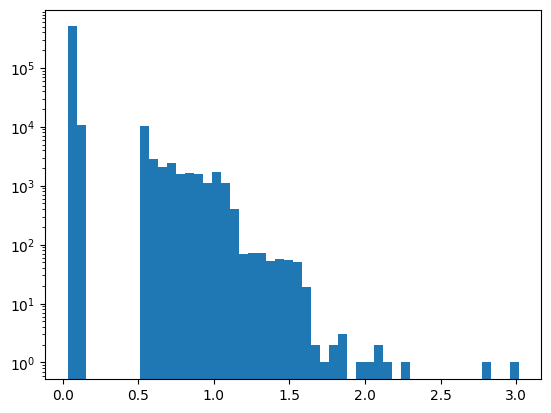

In [16]:
plt.hist(df["Risk"], bins=50)
plt.yscale('log')

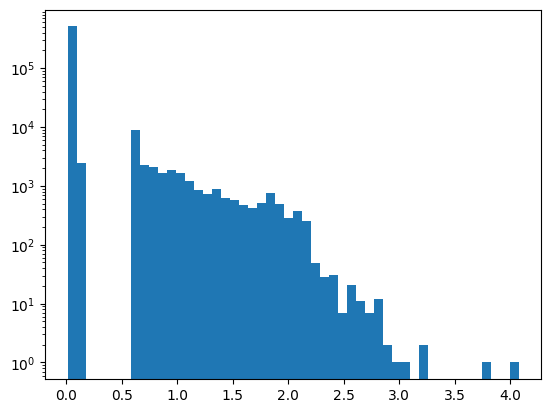

In [19]:
plt.hist(df["Risk"], bins=50)
plt.yscale("log")

In [5]:
from custom.util.data_manipulation import load_and_process_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
X, y, numeric_columns, categorical_columns = load_and_process_data(r'data/claims_train.csv', get_dummies=True, scaler="standard")
df = load_and_process_data(r'data/claims_train.csv', get_dummies=False, scaler=None, return_full_df=True)

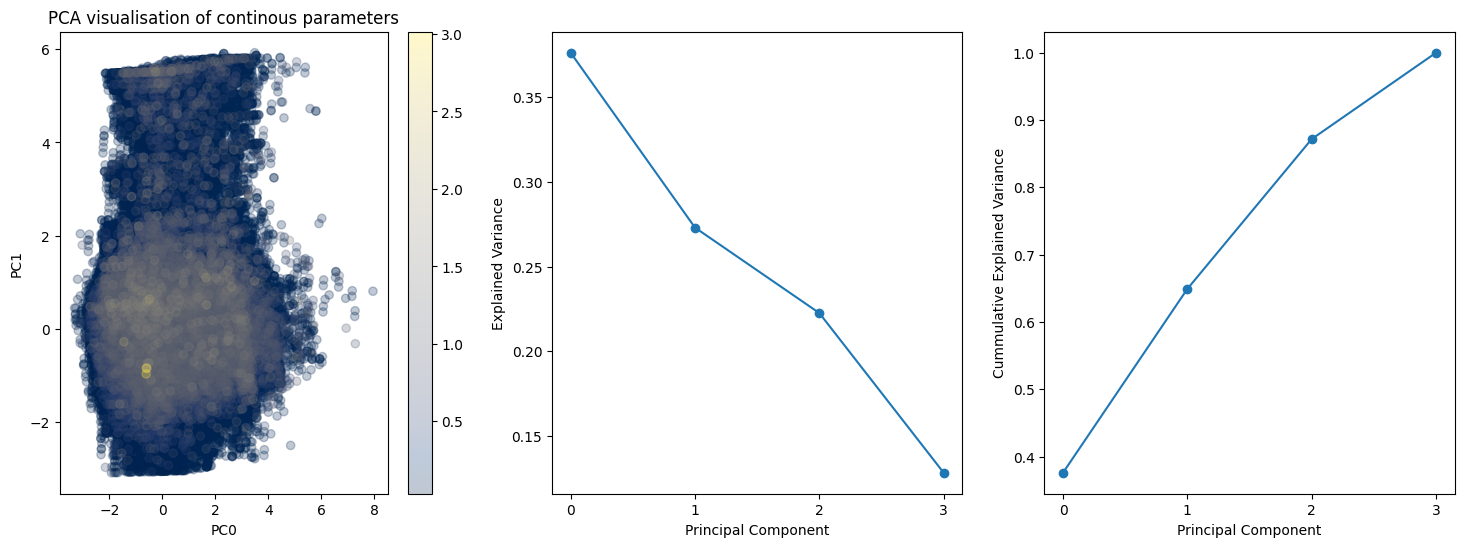

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer

df.reset_index(inplace=True, drop=True)

columns_list = [numeric_columns]

df.sort_values("Risk", inplace=True)

for columns in columns_list:
    plt.figure(figsize=(18, 6))
    ContinousData = pd.DataFrame(StandardScaler().fit_transform(df[columns]), columns=columns)
    pca = PCA().fit(ContinousData)
    pcad = pca.transform(ContinousData)

    plt.subplot(1, 3, 1)
    plt.scatter(pcad[:, 0], pcad[:, 1], c = df["Risk"], alpha=0.25, cmap='cividis')
    plt.title("PCA visualisation of continous parameters")
    plt.xlabel("PC0")
    plt.ylabel("PC1")
    plt.colorbar()


    plt.subplot(1, 3, 2)
    plt.plot(pca.explained_variance_ratio_, marker = "o")

    plt.xticks(range(len(columns)))
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance")
    plt.subplot(1, 3, 3)
    plt.plot([sum(pca.explained_variance_ratio_[:i+1]) for i, ratio in enumerate(pca.explained_variance_ratio_)], marker = "o")
    plt.xticks(range(len(columns)))
    plt.xlabel("Principal Component")
    plt.ylabel("Cummulative Explained Variance")


In [23]:
high_risk_idx = df[df['ClaimNb'] > 0].index
low_risk_idx = df[df['ClaimNb'] == 0].sample(n=len(high_risk_idx)).index
subset_X = X.iloc[high_risk_idx.union(low_risk_idx)]
subset_X.reset_index(inplace=True, drop=True)
subset_y = y.iloc[high_risk_idx.union(low_risk_idx)].copy()
subset_y.reset_index(inplace=True, drop=True)

In [27]:
import umap
from sklearn.preprocessing import QuantileTransformer

subset_X.loc[:,numeric_columns] = StandardScaler().fit_transform(subset_X[numeric_columns])

umaped = umap.UMAP(n_neighbors=50, min_dist=0.1, init='random', target_weight=0.5).fit_transform(subset_X)

/tmp/ipykernel_277166/3345578810.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_X[numeric_columns] = StandardScaler().fit_transform(subset_X[numeric_columns])


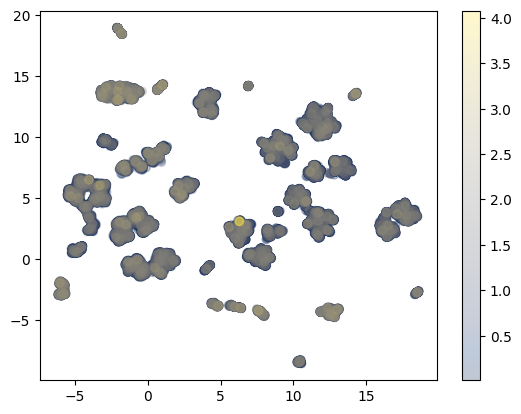

In [28]:
idx = subset_y.sort_values().index

plt.scatter(umaped[idx, 0], umaped[idx, 1], c = subset_y.iloc[idx], alpha=0.25, cmap='cividis')
plt.colorbar()

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from itertools import combinations

def auto_check_interactions(df, target, features, categorical_features=[]):
    """
    Checks all pairs of features for interactions using AIC.
    
    Args:
        df: The dataframe
        target: String, the risk column name (e.g., 'Risk_new')
        features: List of continuous/numerical feature names
        categorical_features: List of categorical feature names
    """
    # 1. Prepare formula strings for categorical data
    # Statsmodels uses C() to denote categorical variables
    proc_features = [f"C({f})" if f in categorical_features else f for f in features]
    
    # 2. Build and fit the Baseline Model (Main Effects only)
    base_formula = f"{target} ~ {' + '.join(proc_features)}"
    try:
        base_model = smf.ols(base_formula, data=df).fit()
        base_aic = base_model.aic
    except Exception as e:
        return f"Error fitting baseline: {e}"

    print(f"Baseline AIC: {base_aic:.2f}")
    print("-" * 50)
    print(f"{'Interaction Pair':<40} | {'AIC Change':<10} | {'Status'}")
    print("-" * 50)

    results = []
    seen = set()
    # 3. Test every combination of feature pairs
    for f1, f2 in combinations(proc_features, 2):
        # Interaction formula: Base + f1:f2
        interaction_terms = list()
        test_formulas = list()

        interaction_term = f"{f1}:{f2}"
        test_formula = f"{base_formula} + {interaction_term}"

        interaction_terms.append(interaction_term)
        test_formulas.append(test_formula)
        
        if not f1 in categorical_features and not f2 in categorical_features:
            for interact in [f"I({f1} / ({f2} + 1e-6))", f"I({f1} - {f2})"]:
                interaction_terms.append(interact)
                test_formulas.append(f"{base_formula} + {interact}")
            for interact in [f"I({f1}**2)", f"I({f2}**2)"]:
                if not interact in seen:
                    interaction_terms.append(interact)
                    test_formulas.append(f"{base_formula} + {interact}")
                seen.add(interact)

        for interaction_term, test_formula in zip(interaction_terms, test_formulas):
            try:
                test_model = smf.ols(test_formula, data=df).fit()
                delta_aic = test_model.aic - base_aic
                
                # Significant if AIC decreases (delta is negative)
                if delta_aic < -2:
                    status = "IMPROVED"
                elif delta_aic > 2:
                    status = "WORSE"
                else:
                    status = "neutral"
                    
                results.append({
                    'interaction': interaction_term,
                    'delta_aic': delta_aic,
                    'status': status,
                    'p_value': test_model.pvalues.iloc[-1]
                })
                
                # Print significant improvements immediately
                if delta_aic < -2:
                    print(f"{interaction_term:<40} | {delta_aic:>10.2f} | {status}")
                    
            except:
                continue # Skip pairs that cause matrix errors (singularities)

    # 4. Return sorted summary
    summary_df = pd.DataFrame(results).sort_values('delta_aic')
    return summary_df

In [ ]:
df[numeric_columns] = StandardScaler().fit_transform(df[numeric_columns])

report = auto_check_interactions(df, target='Risk', features=numeric_columns, categorical_features=categorical_columns)
report

# Baseline AIC: -48155.44
# --------------------------------------------------
# Interaction Pair                         | AIC Change | Status
# --------------------------------------------------
# BonusMalus:Density                       |     -16.34 | IMPROVED
# BonusMalus:DrivAge                       |     -11.48 | IMPROVED
# BonusMalus:C(VehBrand)                   |    -134.43 | IMPROVED
# BonusMalus:C(VehPower)                   |     -36.73 | IMPROVED
# BonusMalus:C(VehAge)                     |    -102.65 | IMPROVED
# BonusMalus:C(DrivAgeCat)                 |    -115.41 | IMPROVED
# BonusMalus:C(BonusMalusBin)              |      -6.35 | IMPROVED
# BonusMalus:C(Region)                     |    -114.05 | IMPROVED
# BonusMalus:C(Area)                       |     -33.23 | IMPROVED
# Density:C(VehPower)                      |     -16.70 | IMPROVED
# Density:C(VehAge)                        |     -31.61 | IMPROVED
# Density:C(BonusMalusBin)                 |     -21.09 | IMPROVED
# Density:C(Region)                        |      -8.61 | IMPROVED
# DrivAge:C(VehBrand)                      |     -29.84 | IMPROVED
# DrivAge:C(VehPower)                      |     -42.86 | IMPROVED
# DrivAge:C(DrivAgeCat)                    |     -49.83 | IMPROVED
# DrivAge:C(BonusMalusBin)                 |     -15.00 | IMPROVED
# DrivAge:C(Region)                        |     -58.71 | IMPROVED
# DrivAge:C(Area)                          |     -23.50 | IMPROVED
# DrivAge:C(VehGas)                        |      -2.09 | IMPROVED
# C(VehBrand):C(VehPower)                  |    -517.71 | IMPROVED
# C(VehBrand):C(VehAge)                    |   -2244.02 | IMPROVED
# C(VehBrand):C(DrivAgeCat)                |     -27.56 | IMPROVED
# C(VehBrand):C(BonusMalusBin)             |    -197.08 | IMPROVED
# C(VehBrand):C(VehGas)                    |    -347.59 | IMPROVED
# C(VehPower):C(VehAge)                    |   -1653.58 | IMPROVED
# C(VehPower):C(DrivAgeCat)                |     -17.75 | IMPROVED
# C(VehPower):C(BonusMalusBin)             |     -29.22 | IMPROVED
# C(VehPower):C(VehGas)                    |    -110.98 | IMPROVED
# C(VehAge):C(DrivAgeCat)                  |      -6.10 | IMPROVED
# C(VehAge):C(BonusMalusBin)               |    -175.31 | IMPROVED

Baseline AIC: -42317.31
--------------------------------------------------
Interaction Pair                         | AIC Change | Status
--------------------------------------------------
BonusMalus:Density                       |     -26.57 | IMPROVED
I(BonusMalus**2)                         |    -116.52 | IMPROVED
I(Density**2)                            |     -14.82 | IMPROVED
I(BonusMalus / (DrivAge + 1e-6))         |     -11.49 | IMPROVED
I(DrivAge**2)                            |     -63.72 | IMPROVED
BonusMalus:VehAge                        |     -43.93 | IMPROVED
I(BonusMalus / (VehAge + 1e-6))          |      -3.84 | IMPROVED
I(VehAge**2)                             |    -358.82 | IMPROVED
Density:VehAge                           |      -3.90 | IMPROVED


,interaction,delta_aic,status,p_value
12,I(VehAge**2),-358.821950,IMPROVED,1.868748e-80
3,I(BonusMalus**2),-116.523563,IMPROVED,1.332584e-27
8,I(DrivAge**2),-63.719034,IMPROVED,5.202205e-16
9,BonusMalus:VehAge,-43.929168,IMPROVED,1.226413e-11
0,BonusMalus:Density,-26.566029,IMPROVED,9.057311e-08
4,I(Density**2),-14.815744,IMPROVED,4.119453e-05
6,I(BonusMalus / (DrivAge + 1e-6)),-11.492471,IMPROVED,2.395433e-04
16,Density:VehAge,-3.904993,IMPROVED,1.509864e-02
10,I(BonusMalus / (VehAge + 1e-6)),-3.840129,IMPROVED,1.566531e-02
11,I(BonusMalus - VehAge),0.000000,neutral,0.000000e+00


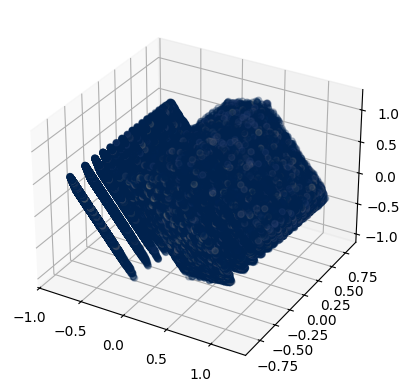

In [ ]:

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection="3d")

# Plot the points for the current species
ax.scatter3D(pcad[:, 0], pcad[:, 1], pcad[:, 2], 
            c=df["Risk"], cmap='cividis', alpha=0.25)
plt.show()
